In [ ]:
import os
import cv2
import re
import csv
import h5py
import numpy as np
import pandas as pd
import tkinter as tk
from tkinter import filedialog, simpledialog, messagebox

root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()

print("Opening file selectors...")
input_h5_path = filedialog.askopenfilename(title="Select Original H5 Video File", filetypes=[("H5 Files", "*.h5")])
csv_input_path = filedialog.askopenfilename(title="Select Centerline CSV (pharynx_axis_coordinates.csv)", filetypes=[("CSV Files", "*.csv")])
particle_folder = filedialog.askdirectory(title="Select Moving Particle Mask Folder")
fixed_point_folder = filedialog.askdirectory(title="Select Fixed Point Mask Folder")
output_trajectory_csv = filedialog.asksaveasfilename(title="Save Processed Trajectory As...", filetypes=[("CSV Files", "*.csv")], defaultextension=".csv")

if not all([input_h5_path, csv_input_path, particle_folder, fixed_point_folder, output_trajectory_csv]):
    print("Execution cancelled. Missing inputs.")
    exit()

print("Loading data files into memory...")
df_skeleton = pd.read_csv(csv_input_path)
skeleton_lookup = {
    frame_id: group.sort_values('node_id')[['x_pixel', 'y_pixel']].to_numpy()
    for frame_id, group in df_skeleton.groupby('frame_id')
}

particle_files = sorted([f for f in os.listdir(particle_folder) if f.endswith(('.png', '.jpg'))])
particle_map = {int(re.search(r'\d+', f).group()): f for f in particle_files if re.search(r'\d+', f)}

fixed_files = sorted([f for f in os.listdir(fixed_point_folder) if f.endswith(('.png', '.jpg'))])
fixed_point_map = {int(re.search(r'\d+', f).group()): f for f in fixed_files if re.search(r'\d+', f)}

def find_subpixel_centerline_anchor(skeleton_points, target_pt):
    """Finds the continuous sub-pixel projection point on the centerline closest to target_pt."""
    distances = np.sum((skeleton_points - target_pt) ** 2, axis=1)
    closest_idx = np.argmin(distances)
    
    start_idx = max(0, closest_idx - 1)
    end_idx = min(len(skeleton_points) - 1, closest_idx + 1)
    
    best_proj_pt = skeleton_points[closest_idx]
    min_seg_dist = distances[closest_idx]
    best_node_fractional_idx = float(closest_idx)
    
    for i in range(start_idx, end_idx):
        p1 = skeleton_points[i]
        p2 = skeleton_points[i+1]
        
        segment_vec = p2 - p1
        seg_len_sq = np.sum(segment_vec ** 2)
        if seg_len_sq == 0: continue
        
        t = np.dot(target_pt - p1, segment_vec) / seg_len_sq
        t = np.clip(t, 0.0, 1.0)
        
        proj_pt = p1 + t * segment_vec
        dist_sq = np.sum((target_pt - proj_pt) ** 2)
        
        if dist_sq < min_seg_dist:
            min_seg_dist = dist_sq
            best_proj_pt = proj_pt
            best_node_fractional_idx = i + t
            
    return best_proj_pt, best_node_fractional_idx

def get_pure_unit_basis(anchor_pt, landmark_com):
    """Generates a pure, unit-length rigid rotational matrix immune to scaling or shear."""
    vec_ab = landmark_com - anchor_pt
    norm_ab = np.linalg.norm(vec_ab)
    if norm_ab > 0:
        ux = vec_ab / norm_ab
    else:
        ux = np.array([1.0, 0.0])
    uy = np.array([-ux[1], ux[0]])
    return ux, uy





user_satisfied = False

while not user_satisfied:
    
    calibration_frame_id = simpledialog.askinteger(
        "Calibration Frame", 
        "Enter the exact Frame ID where your Special Point is clearly visible:",
        initialvalue=854, minvalue=0
    )

    if calibration_frame_id is None:
        print("Execution cancelled during re-calibration step.")
        exit()

    print(f"\nLoading Frame {calibration_frame_id} from H5 video...")
    special_point_coords = []

    with h5py.File(input_h5_path, 'r') as h5_in:
        video_key = list(h5_in.keys())[0]
        frame_img = h5_in[video_key][calibration_frame_id]
        if frame_img.dtype != np.uint8:
            frame_img = cv2.normalize(frame_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        frame_img_disp = cv2.cvtColor(frame_img, cv2.COLOR_GRAY2BGR) if len(frame_img.shape) == 2 else frame_img.copy()

    if calibration_frame_id in skeleton_lookup:
        sk_pts = skeleton_lookup[calibration_frame_id].astype(np.int32)
        for i in range(len(sk_pts) - 1):
            cv2.line(frame_img_disp, tuple(sk_pts[i]), tuple(sk_pts[i+1]), (255, 255, 0), 2)

    def click_event_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            special_point_coords.append((x, y))
            print(f"--> Click Registered! Center anchor set at X: {x}, Y: {y}")

    window_name = f"CALIBRATION WINDOW: Left-Click the Lumen Center (Frame {calibration_frame_id})"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(window_name, click_event_callback)

    while True:
        cv2.imshow(window_name, frame_img_disp)
        key = cv2.waitKey(20) & 0xFF
        if len(special_point_coords) > 0 or key == 27:
            break
    cv2.destroyWindow(window_name)
    cv2.waitKey(1)

    if not special_point_coords:
        messagebox.showwarning("Warning", "No point clicked! Re-opening calibration phase.")
        continue

    special_coord = np.array(special_point_coords[0])

    if calibration_frame_id not in fixed_point_map:
        messagebox.showerror("Error", f"Frame {calibration_frame_id} does not exist in your Landmark folder! Select a different frame.")
        continue
        
    f_mask_img = cv2.imread(os.path.join(fixed_point_folder, fixed_point_map[calibration_frame_id]), cv2.IMREAD_GRAYSCALE)
    _, binary_f_mask = cv2.threshold(f_mask_img, 1, 255, cv2.THRESH_BINARY)
    f_moments = cv2.moments(binary_f_mask)
    if f_moments["m00"] == 0:
        messagebox.showerror("Error", "Landmark mask is blank on this frame! Select a different frame.")
        continue
    fixed_com_calib = np.array([f_moments["m10"] / f_moments["m00"], f_moments["m01"] / f_moments["m00"]])

    skeleton_points_calib = skeleton_lookup[calibration_frame_id]
    anchor_pt_calib, _ = find_subpixel_centerline_anchor(skeleton_points_calib, fixed_com_calib)
    ux_calib, uy_calib = get_pure_unit_basis(anchor_pt_calib, fixed_com_calib)

    vec_to_sp = special_coord - anchor_pt_calib
    c_x_offset = np.dot(vec_to_sp, ux_calib)
    c_y_offset = np.dot(vec_to_sp, uy_calib)


    processed_frames_data = {}

    for frame_id, skeleton_points in skeleton_lookup.items():
        if (frame_id not in particle_map) or (frame_id not in fixed_point_map):
            continue
            
        p_mask_img = cv2.imread(os.path.join(particle_folder, particle_map[frame_id]), cv2.IMREAD_GRAYSCALE)
        f_mask_img = cv2.imread(os.path.join(fixed_point_folder, fixed_point_map[frame_id]), cv2.IMREAD_GRAYSCALE)
        
        if p_mask_img is None or f_mask_img is None:
            continue
            
        # Particle Center of Mass
        _, binary_p_mask = cv2.threshold(p_mask_img, 1, 255, cv2.THRESH_BINARY)
        p_moments = cv2.moments(binary_p_mask)
        if p_moments["m00"] == 0: continue
        cm_x_px, cm_y_px = p_moments["m10"] / p_moments["m00"], p_moments["m01"] / p_moments["m00"]
        particle_coord = np.array([[cm_x_px, cm_y_px]])
        
        _, binary_f_mask = cv2.threshold(f_mask_img, 1, 255, cv2.THRESH_BINARY)
        f_moments = cv2.moments(binary_f_mask)
        if f_moments["m00"] == 0: continue
        current_fixed_com = np.array([f_moments["m10"] / f_moments["m00"], f_moments["m01"] / f_moments["m00"]])
        
        current_anchor_pt, _ = find_subpixel_centerline_anchor(skeleton_points, current_fixed_com)
        ux_current, uy_current = get_pure_unit_basis(current_anchor_pt, current_fixed_com)
        temporary_2d_special_coord = current_anchor_pt + (c_x_offset * ux_current) + (c_y_offset * uy_current)
        
        _, fractional_special_idx = find_subpixel_centerline_anchor(skeleton_points, temporary_2d_special_coord)
        
        discrete_special_node_idx = int(np.round(fractional_special_idx))
        discrete_special_node_idx = np.clip(discrete_special_node_idx, 0, len(skeleton_points) - 1)
        
        final_discrete_special_pt = skeleton_points[discrete_special_node_idx]
        
        _, current_particle_fractional_idx = find_subpixel_centerline_anchor(skeleton_points, particle_coord[0])
        
        dx = np.diff(skeleton_points[:, 0])
        dy = np.diff(skeleton_points[:, 1])
        node_spacing_px = np.mean(np.sqrt(dx**2 + dy**2))
        
        closest_discrete_node = np.argmin(np.sum((skeleton_points - particle_coord) ** 2, axis=1))
        shortest_distance_px = np.sqrt(np.sum((skeleton_points[closest_discrete_node] - particle_coord) ** 2))
        closest_skeleton_y_px = skeleton_points[closest_discrete_node][1]
        direction_sign = 1.0 if cm_y_px <= closest_skeleton_y_px else -1.0
        signed_transverse_px = shortest_distance_px * direction_sign
        
        node_delta_mixed = current_particle_fractional_idx - float(discrete_special_node_idx)
        longitudinal_from_special_px = node_delta_mixed * node_spacing_px
        
        processed_frames_data[frame_id] = {
            'skeleton': skeleton_points,
            'particle': np.array([cm_x_px, cm_y_px]),
            'special_point': final_discrete_special_pt,
            'long_px': longitudinal_from_special_px,
            'trans_px': signed_transverse_px
        }

    valid_frame_ids = sorted(list(processed_frames_data.keys()))
    
    with h5py.File(input_h5_path, 'r') as h5_in:
        video_key = list(h5_in.keys())[0]
        h5_video_data = h5_in[video_key]

        def update_frame_viewer(trackbar_pos):
            if trackbar_pos >= len(valid_frame_ids):
                trackbar_pos = len(valid_frame_ids) - 1
            current_frame_id = valid_frame_ids[trackbar_pos]
            raw_img = h5_video_data[current_frame_id]
            if raw_img.dtype != np.uint8:
                raw_img = cv2.normalize(raw_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            disp_img = cv2.cvtColor(raw_img, cv2.COLOR_GRAY2BGR) if len(raw_img.shape) == 2 else raw_img.copy()
            
            frame_metrics = processed_frames_data[current_frame_id]
            sk_pts = frame_metrics['skeleton'].astype(np.int32)
            p_coord = frame_metrics['particle'].astype(np.int32)
            sp_coord = frame_metrics['special_point'].astype(np.int32)
            
            for i in range(len(sk_pts) - 1):
                cv2.line(disp_img, tuple(sk_pts[i]), tuple(sk_pts[i+1]), (255, 255, 0), 1)
            cv2.rectangle(disp_img, (sp_coord[0]-5, sp_coord[1]-5), (sp_coord[0]+5, sp_coord[1]+5), (0, 0, 255), -1)
            cv2.circle(disp_img, tuple(p_coord), 5, (0, 255, 0), -1)
            
            cv2.putText(disp_img, f"Frame Index: {current_frame_id}", (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
            cv2.putText(disp_img, "Press [ESC] to Accept & Save | Press [DELETE / BACKSPACE] to Re-Calibrate", (15, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1, cv2.LINE_AA)
            cv2.imshow(viewer_window_name, disp_img)

        viewer_window_name = "TRAJECTORY VERIFICATION VIEWER"
        cv2.namedWindow(viewer_window_name, cv2.WINDOW_NORMAL)
        cv2.createTrackbar("Frame Scrolling", viewer_window_name, 0, len(valid_frame_ids) - 1, update_frame_viewer)
        update_frame_viewer(0)
        
        while True:
            key_stroke = cv2.waitKey(30) & 0xFF
            if key_stroke == 27:
                user_satisfied = True
                print("\n--> Verification approved! Compiling trajectory data output...")
                break
            elif key_stroke in [127, 8]:
                print("\n--> Reset requested by user. Returning to Calibration Frame input step...")
                break
                
        cv2.destroyWindow(viewer_window_name)
        cv2.waitKey(1)

trajectory_rows = []
for fid in sorted(list(processed_frames_data.keys())):
    trajectory_rows.append({
        'Frame': fid,
        'Longitudinal_From_Special': processed_frames_data[fid]['long_px'],
        'Transverse_Dist': processed_frames_data[fid]['trans_px']
    })

df_out = pd.DataFrame(trajectory_rows)
df_out.to_csv(output_trajectory_csv, index=False)
print(f"\nProcessing complete! Discrete node index reference trajectory saved to: {output_trajectory_csv}")

Opening file selectors...
Loading data files into memory...

Loading Frame 285 from H5 video...
--> Click Registered! Center anchor set at X: 254, Y: 286
--> Sub-Pixel Rotational Matrix Extracted!
Processing tracking metrics across all frames...

--> Reset requested by user. Returning to Calibration Frame input step...

Loading Frame 288 from H5 video...
--> Click Registered! Center anchor set at X: 257, Y: 282
--> Sub-Pixel Rotational Matrix Extracted!
Processing tracking metrics across all frames...

--> Reset requested by user. Returning to Calibration Frame input step...

Loading Frame 288 from H5 video...
--> Click Registered! Center anchor set at X: 256, Y: 283
--> Sub-Pixel Rotational Matrix Extracted!
Processing tracking metrics across all frames...

--> Verification approved! Compiling trajectory data output...

Processing complete! Discrete node index reference trajectory saved to: /Users/dharani/Desktop/data/1-1 Masks/279-296/trajectory.csv


: 

/var/folders/ss/_s017s7n0lz05fqdp0pjzryh0000gn/T/ipykernel_88703/3159149347.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc='upper right')


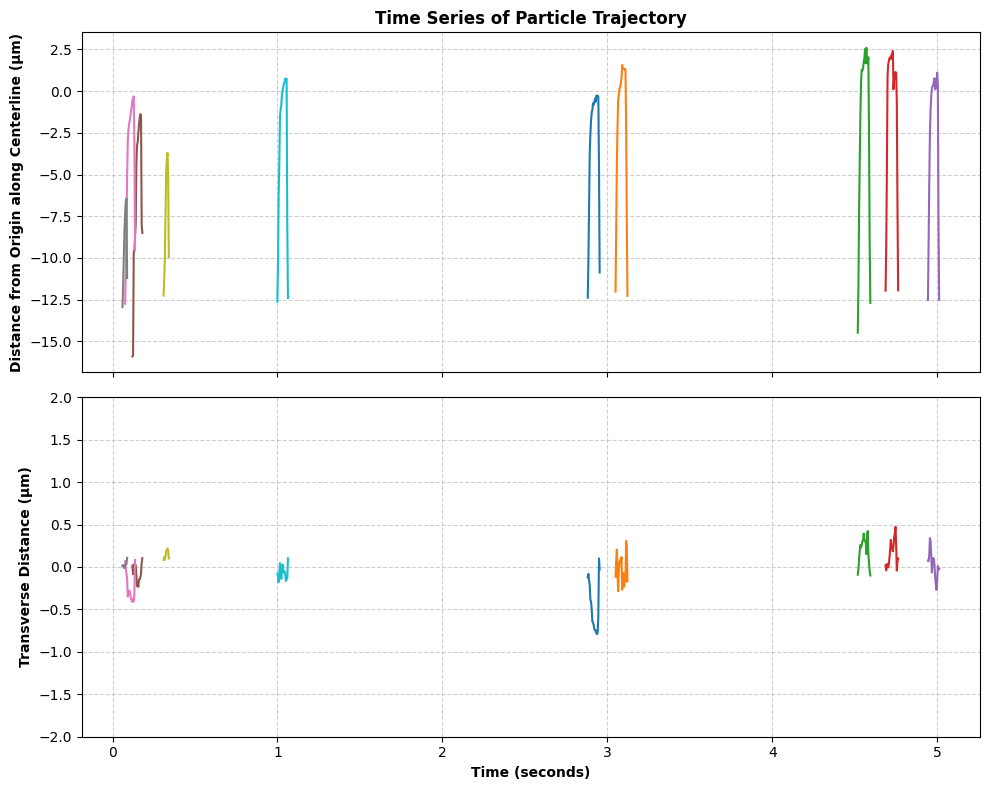

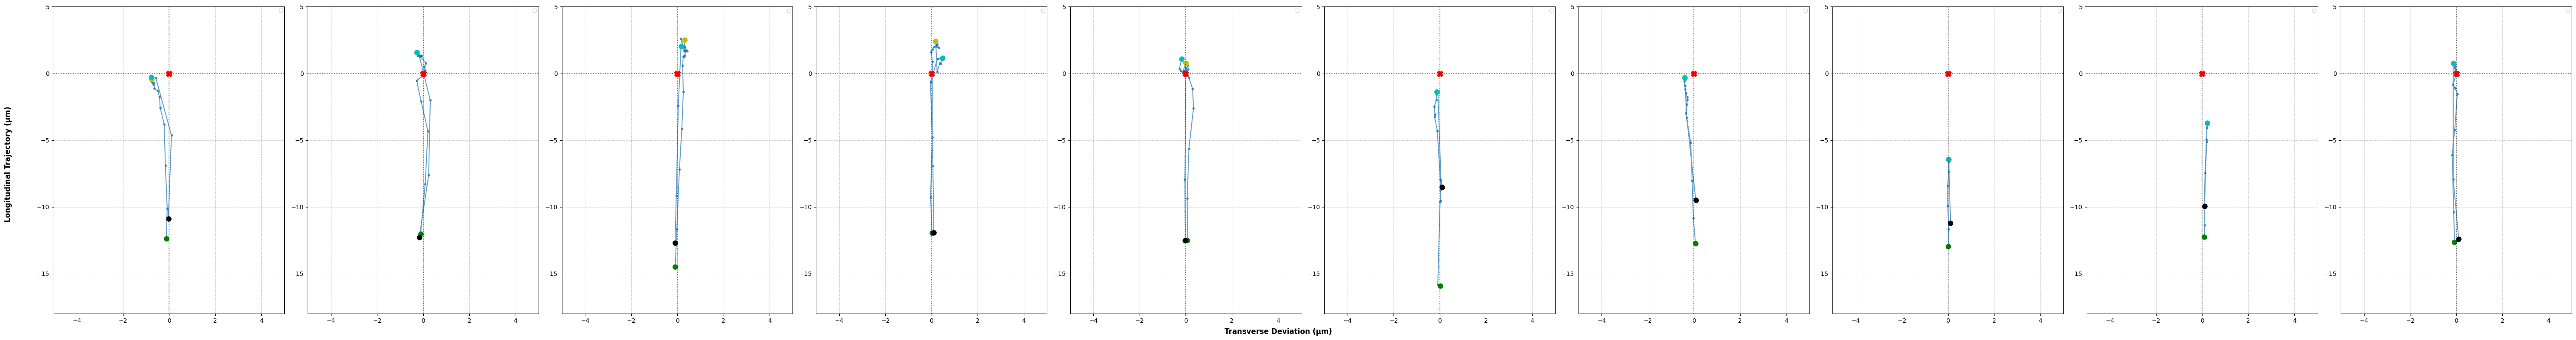

: 

In [ ]:
import os
import math
import pandas as pd
import tkinter as tk
from tkinter import filedialog, ttk
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================
UM_PER_PIXEL = 0.04
FPS = 249.2
TRANS_Y_LIMITS = [-2, 2] 
# ==========================================

root = tk.Tk()
root.attributes('-topmost', True) 
root.withdraw()

# --- STEP 1: SELECT FILES ---
all_csv_paths = []
while True:
    csv_paths = filedialog.askopenfilenames(
        title=f"Select CSVs (Total: {len(all_csv_paths)}) - Click CANCEL to plot", 
        filetypes=[("CSV Files", "*.csv")]
    )
    if not csv_paths: break
    all_csv_paths.extend(csv_paths)
all_csv_paths = list(dict.fromkeys(all_csv_paths))

if not all_csv_paths:
    print("No files selected.")
    exit()

# --- STEP 2: CUSTOM DIALOG FOR INVERSION ---
inversion_map = {}
def open_inversion_dialog(paths):
    dialog = tk.Toplevel(root)
    dialog.title("Set Orientation (Checked = Invert)")
    vars = {}
    
    for path in paths:
        fname = os.path.basename(path)
        var = tk.BooleanVar(value=True) # Default Invert = True
        chk = ttk.Checkbutton(dialog, text=fname, variable=var)
        chk.pack(anchor="w", padx=10, pady=2)
        vars[path] = var
        
    def on_confirm():
        for path, var in vars.items():
            inversion_map[path] = var.get()
        dialog.destroy()
        
    ttk.Button(dialog, text="Confirm & Plot", command=on_confirm).pack(pady=10)
    root.wait_window(dialog)

open_inversion_dialog(all_csv_paths)

# --- STEP 3: PLOTTING ---
# FIGURE 1: SHARED TIME-SERIES PLOTS
fig_ts, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# SETUP SINGLE-ROW SPATIAL GRID
num_plots = len(all_csv_paths)
# One row, as many columns as there are files
fig_spatial, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 8))

# Ensure axes is iterable (handles the case of 1 file)
if num_plots == 1:
    axes_flat = [axes]
else:
    axes_flat = axes

for i, path in enumerate(all_csv_paths):
    df_traj = pd.read_csv(path)
    df_traj['Time_s'] = df_traj['Frame'] / FPS
    
    direction_multiplier = -1.0 if inversion_map.get(path, True) else 1.0
    df_traj['Long_Special_um'] = df_traj['Longitudinal_From_Special'] * UM_PER_PIXEL * direction_multiplier
    df_traj['Transverse_Dist_um'] = df_traj['Transverse_Dist'] * UM_PER_PIXEL
    
    # Time-series plots
    ax1.plot(df_traj['Time_s'], df_traj['Long_Special_um']) 
    ax2.plot(df_traj['Time_s'], df_traj['Transverse_Dist_um'])
    
    ax = axes_flat[i]
    ax.plot(df_traj['Transverse_Dist_um'], df_traj['Long_Special_um'], 
             marker='o', markersize=3, alpha=0.7, color='tab:blue')
    ax.plot(0, 0, marker='X', color='red', markersize=10)
    
    peaks, _ = find_peaks(df_traj['Long_Special_um'], prominence=0.1)
    positive_peaks = [p for p in peaks if df_traj['Long_Special_um'].iloc[p] > 0]
    first_max_idx = positive_peaks[0] if positive_peaks else peaks[0]
    last_max_idx = positive_peaks[-1] if positive_peaks else peaks[-1]
    
    # Plot markers with labels
    ax.plot(df_traj['Transverse_Dist_um'].iloc[0], df_traj['Long_Special_um'].iloc[0], 'go', markersize=8) 
    ax.plot(df_traj['Transverse_Dist_um'].iloc[-1], df_traj['Long_Special_um'].iloc[-1], 'ko', markersize=8) 
    ax.plot(df_traj['Transverse_Dist_um'].iloc[first_max_idx], df_traj['Long_Special_um'].iloc[first_max_idx], 'yo', markersize=8) 
    ax.plot(df_traj['Transverse_Dist_um'].iloc[last_max_idx], df_traj['Long_Special_um'].iloc[last_max_idx], 'co', markersize=8)
    
    # Add the legend
    ax.legend(fontsize=7, loc='upper right')
    
    ax.set_ylim([-18, 5])
    ax.set_xlim([-5, 5])
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5)
    ax.axhline(0, color='black', linestyle=':', alpha=0.5)

# Add Shared Title and Labels centered for the whole row
fig_spatial.text(0.5, 0.01, 'Transverse Deviation (µm)', ha='center', fontweight='bold', fontsize=12)
fig_spatial.text(0.01, 0.5, 'Longitudinal Trajectory (µm)', va='center', rotation='vertical', fontweight='bold', fontsize=12)

fig_spatial.tight_layout(rect=[0.02, 0.02, 1, 0.98])

# Time series aesthetics
ax1.set_ylabel('Distance from Origin along Centerline (µm)', fontweight='bold')
ax1.set_title('Time Series of Particle Trajectory', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.set_xlabel('Time (seconds)', fontweight='bold')
ax2.set_ylabel('Transverse Distance (µm)', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
if TRANS_Y_LIMITS is not None: 
    ax2.set_ylim(TRANS_Y_LIMITS)
    
fig_ts.tight_layout()
plt.show()